## Data Science I project
## Coupon Acceptance: Behavioral and Contextual Influences-Yu-Ting Chu

### 1. Introduction

#### Objective
This project aims to understand the behavioral and contextual factors influencing a customer's decision to accept a discount coupon while inside a vehicle. This kind of analysis has potential applications in location-based marketing, personalized advertising, and understanding user behavior for mobile recommendation systems.

#### Dataset Introduction
We use the **In-Vehicle Coupon Recommendation** dataset from the UCI Machine Learning Repository:  🔗 [Dataset Link](https://archive.ics.uci.edu/dataset/603/in+vehicle+coupon+recommendation)

The dataset contains simulated survey data about passengers who received various types of coupons during a trip and whether they accepted the offer. It includes demographic features (e.g., age, gender), temporal and situational context (e.g., time, weather, destination), and psychological/behavioral indicators (e.g., marital status, education, decision-making).

#### Problem Statement
We aim to solve the following problem:
> "Given user demographics and trip context, can we predict whether the person will accept the coupon?"

This task is framed as a **binary classification** problem and lends itself well to predictive modeling. Additionally, we aim to understand whether certain behavioral and contextual factors significantly affect coupon acceptance through **hypothesis testing**.

### 2. Data Preprocessing

In [53]:
# import package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# Load dataset
url = "https://archive.ics.uci.edu/static/public/603/in+vehicle+coupon+recommendation.zip"
df = pd.read_csv(url)

In [63]:
df

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


In [64]:
print(df.shape)
df.head()

(12684, 26)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [68]:
# Check for missing data
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])


Missing values per column:
 Bar                     107
CoffeeHouse             217
CarryAway               151
RestaurantLessThan20    130
Restaurant20To50        189
dtype: int64


In [69]:
print(df[df.CoffeeHouse.isnull()])

           destination  passanger weather  temperature  time  \
495    No Urgent Place      Alone   Sunny           55   2PM   
496    No Urgent Place  Friend(s)   Sunny           80  10AM   
497    No Urgent Place  Friend(s)   Sunny           80  10AM   
498    No Urgent Place  Friend(s)   Sunny           80   2PM   
499    No Urgent Place  Friend(s)   Sunny           80   2PM   
...                ...        ...     ...          ...   ...   
12409             Home      Alone   Sunny           80   6PM   
12410             Work      Alone   Rainy           55   7AM   
12411             Work      Alone   Snowy           30   7AM   
12412             Work      Alone   Snowy           30   7AM   
12413             Work      Alone   Sunny           80   7AM   

                      coupon expiration  gender age      maritalStatus  ...  \
495          Restaurant(<20)         1d    Male  26  Unmarried partner  ...   
496             Coffee House         2h    Male  26  Unmarried partner  .

In [66]:
# drop unnecessary columns
df = df.drop(["car"], axis=1)

In [71]:
print(df.shape)

(12684, 25)


In [111]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_enc_cols = ['gender', 'age', 'maritalStatus', 'education', 'occupation',
                  'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20',
                  'Restaurant20To50', 'direction_opp', 'destination', 'passanger',
                  'weather', 'temperature', 'time', 'coupon']

df_encoded = df.copy()

for col in label_enc_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Final dataset shape
df_encoded.shape

(12684, 25)

### 3. Exploratory Data Analysis (EDA)

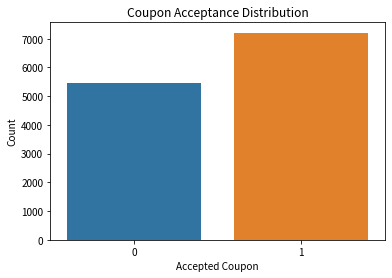

In [77]:
# Distribution of coupon acceptance
sns.countplot(x='Y', data=df)
plt.title("Coupon Acceptance Distribution")
plt.xlabel("Accepted Coupon")
plt.ylabel("Count")
plt.show()

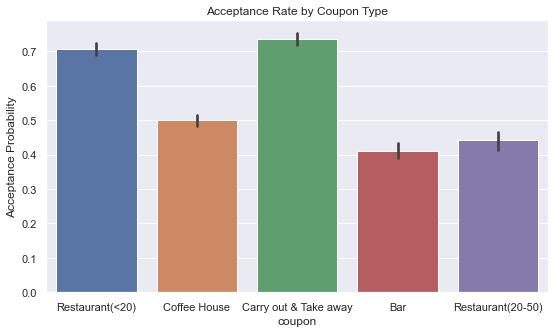

In [106]:
# Acceptance by coupon type
plt.figure(figsize=(9,5))
sns.barplot(x='coupon', y='Y', data=df)
plt.title("Acceptance Rate by Coupon Type")
plt.ylabel("Acceptance Probability")
plt.show()

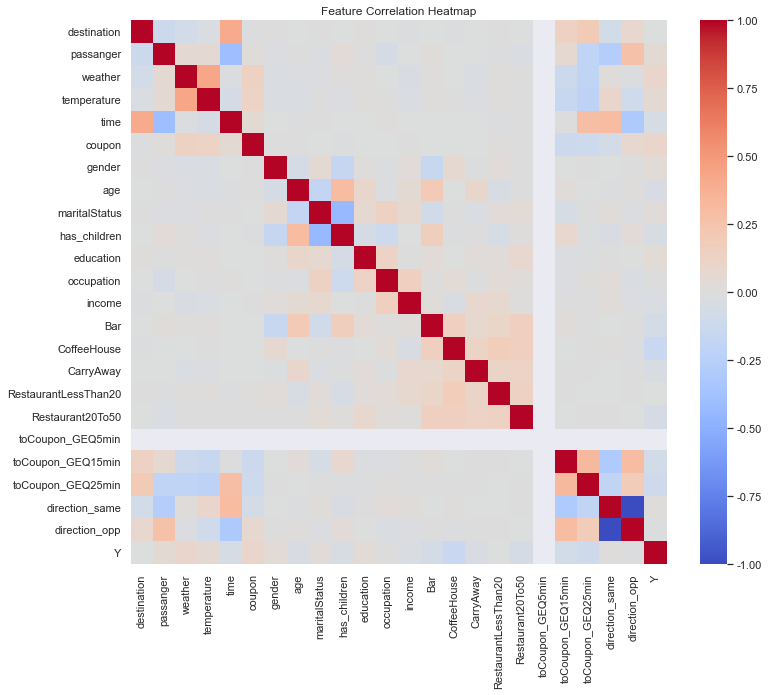

In [112]:
# Heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()